# SolarFlow - Exploration et Analyse des Données

Ce notebook présente une analyse approfondie des données de production solaire et d'irradiance collectées par le pipeline SolarFlow pour la période du **2026-01-01 au 2026-04-27**.

## Objectifs :
1. Statistiques descriptives.
2. Visualisations temporelles et distribution par **Boîtes à moustaches**.
3. Détection d'anomalies et d'incohérences.

In [ ]:
!pip install -q scipy seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime

# Configuration du style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Chargement des données
FILE_PATH = '../output/solarflow_2026-01-01_2026-04-27.csv'
df = pd.read_csv(FILE_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

print(f"Données chargées : {len(df)} lignes.")

Données chargées : 2808 lignes.


## 1. Statistiques descriptives

Nous analysons ici les colonnes numériques pour comprendre les ordres de grandeur.

In [ ]:
cols = ['solar_production_mw', 'ghi', 'dni', 'dhi', 'solar_production_mw_csv', 'consumption_mw']
stats = df[cols].describe().T
stats['non_null_count'] = df[cols].count()
stats = stats[['non_null_count', 'mean', 'std', 'min', 'max']]

display(stats.style.background_gradient(cmap='YlOrRd'))

,non_null_count,mean,std,min,max
solar_production_mw,2750,3126.255636,4589.960137,0.000000,18922.000000
ghi,2808,127.928500,190.260132,0.000000,819.771429
dni,2808,81.893091,137.899199,0.000000,685.300000
dhi,2808,46.035409,59.573310,0.000000,239.778571
solar_production_mw_csv,2063,3651.598764,5021.923430,0.000000,18948.250000
consumption_mw,2063,51575.981944,8298.553317,0.000000,105164.500000


## 2. Visualisations

### a) Évolution temporelle (Aperçu global)

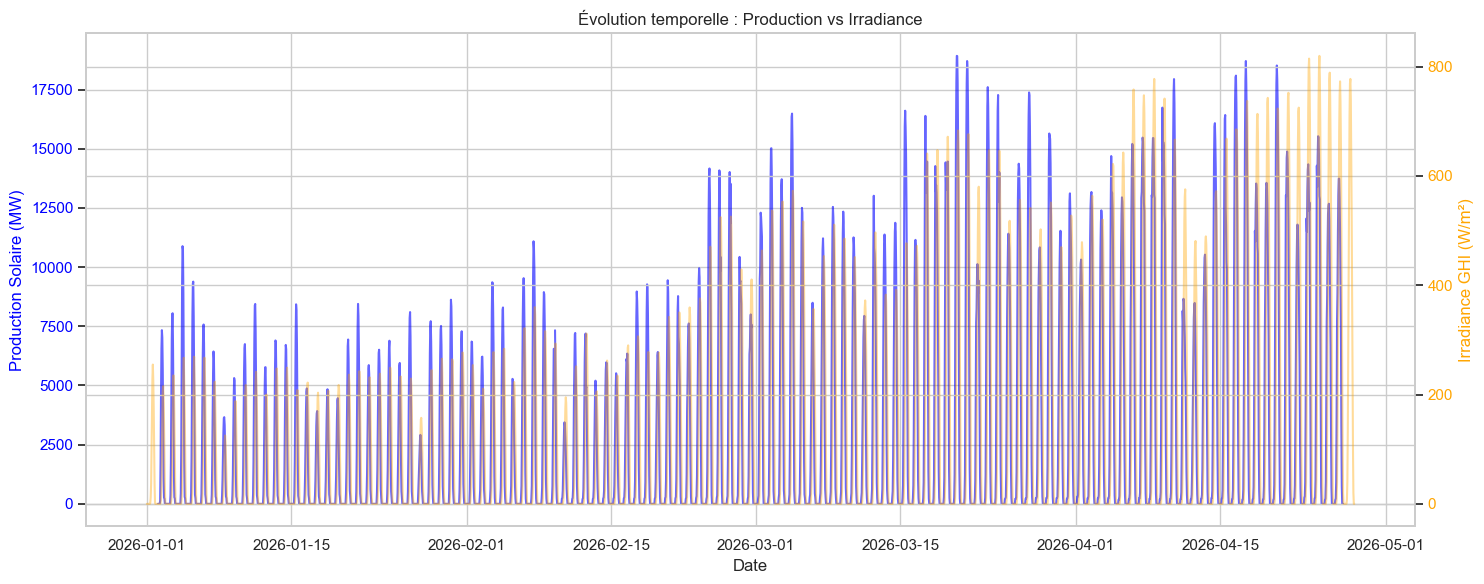

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(df['timestamp'], df['solar_production_mw'], color='blue', alpha=0.6, label='Production (MW)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Production Solaire (MW)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(df['timestamp'], df['ghi'], color='orange', alpha=0.4, label='GHI (W/m²)')
ax2.set_ylabel('Irradiance GHI (W/m²)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Évolution temporelle : Production vs Irradiance')
fig.tight_layout()
plt.show()

### b) Zoom Comparatif (Janvier vs Avril)

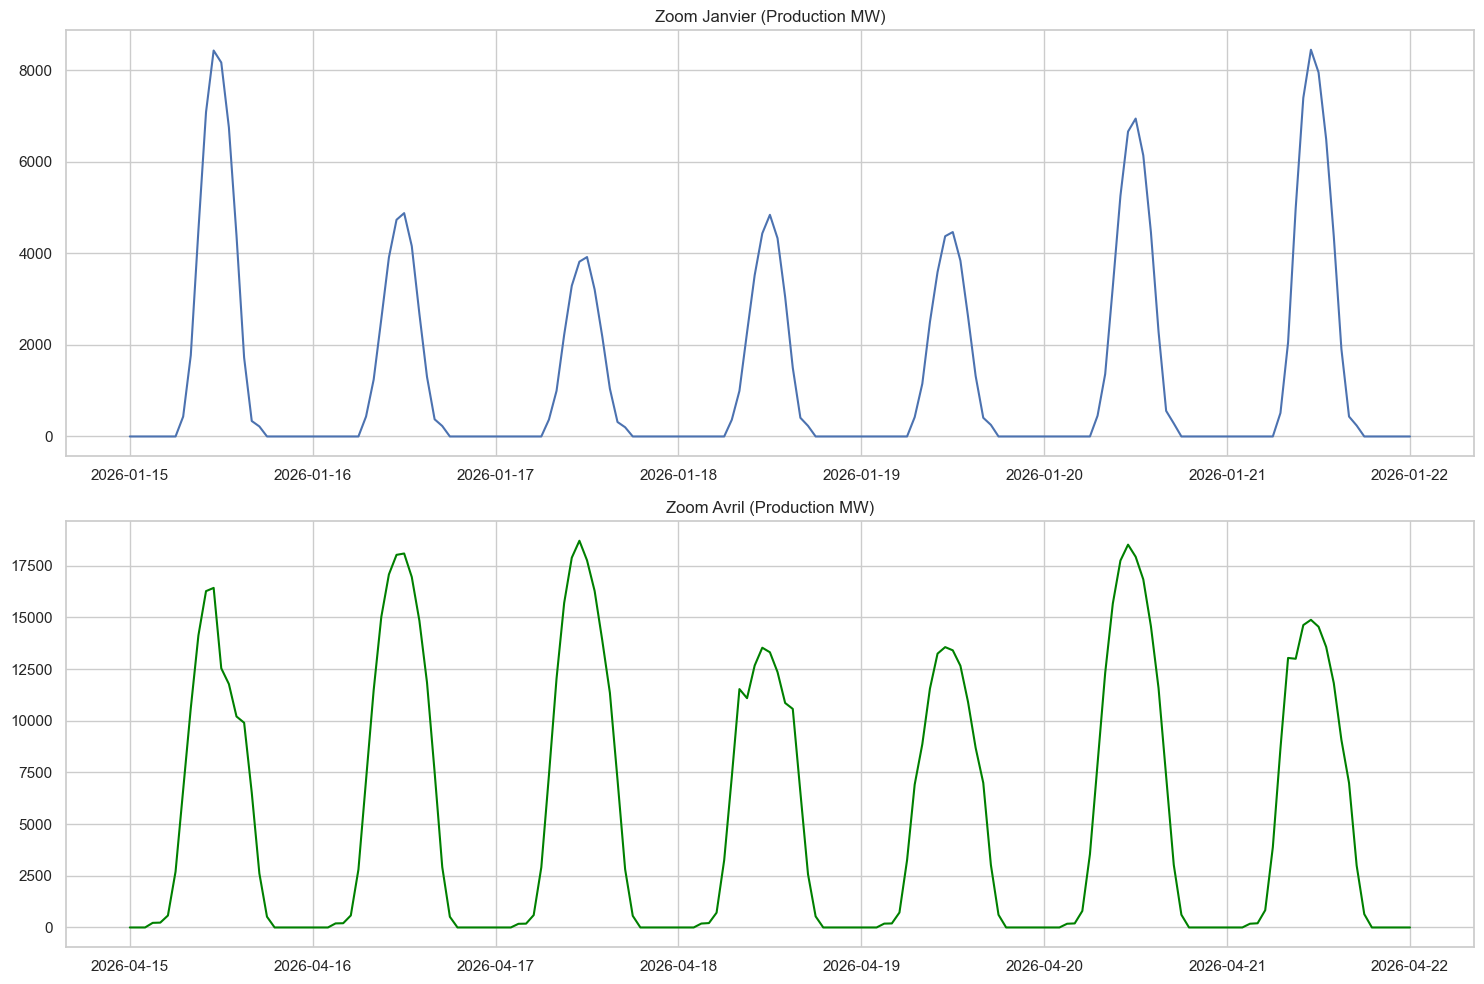

In [ ]:
jan_week = df[(df['timestamp'] >= '2026-01-15') & (df['timestamp'] <= '2026-01-22')]
apr_week = df[(df['timestamp'] >= '2026-04-15') & (df['timestamp'] <= '2026-04-22')]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.plot(jan_week['timestamp'], jan_week['solar_production_mw'], label='Janvier')
ax1.set_title('Zoom Janvier (Production MW)')
ax2.plot(apr_week['timestamp'], apr_week['solar_production_mw'], color='green', label='Avril')
ax2.set_title('Zoom Avril (Production MW)')

plt.tight_layout()
plt.show()

### c) Analyse des Distributions (Boîtes à moustaches optimisées)

Nous séparons ici la production et l'irradiance pour une lecture plus précise. **Les données de nuit (GHI=0) sont exclues** pour ne pas fausser les médianes.

In [ ]:
# Filtrage diurne pour des boîtes représentatives
df_diurne = df[df['ghi'] > 0].copy()

# 1. Boxplot pour la Production Solaire
fig_prod = px.box(df_diurne, y='solar_production_mw', 
                 title="Distribution de la Production Solaire (Données Diurnes)",
                 points='outliers', color_discrete_sequence=['#636EFA'])
fig_prod.update_layout(yaxis_title="Production (MW)")
fig_prod.show()

# 2. Boxplot pour les Irradiances (GHI, DNI, DHI)
df_meteo = df_diurne.melt(id_vars=['timestamp'], value_vars=['ghi', 'dni', 'dhi'], 
                      var_name='Variable', value_name='Irradiance')
fig_meteo = px.box(df_meteo, x='Variable', y='Irradiance', color='Variable',
                  title="Distribution des Irradiances (Données Diurnes)",
                  points='outliers')
fig_meteo.update_layout(yaxis_title="W/m²")
fig_meteo.show()

### d) Profil Horaire (Boîtes à moustaches par heure)

Ce graphique permet de voir la variabilité de la production pour chaque heure de la journée.

In [ ]:
df['heure'] = df['timestamp'].dt.hour
fig_hourly = px.box(df, x='heure', y='solar_production_mw', 
                    title="Variabilité de la Production Solaire par Heure",
                    color_discrete_sequence=['#636EFA'])
fig_hourly.update_layout(xaxis_title="Heure de la journée", yaxis_title="Production (MW)")
fig_hourly.show()

### e) Corrélation GHI vs Production

Analyse de la performance du parc solaire uniquement quand il y a du soleil.

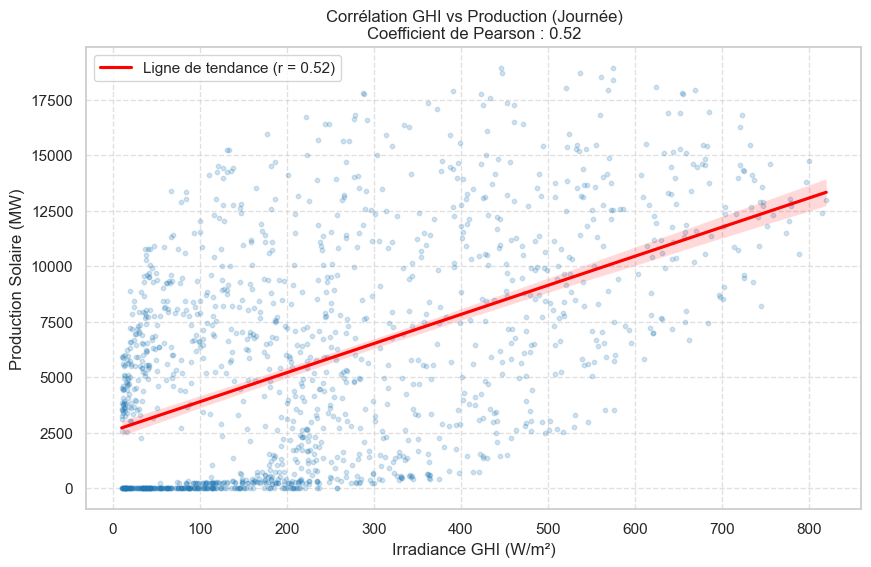

In [ ]:
# Filtrage des données nocturnes
df_day = df[df['ghi'] > 10].copy()

# Calcul de la corrélation de Pearson
pearson_r = df_day['ghi'].corr(df_day['solar_production_mw'])

plt.figure(figsize=(10, 6))
sns.regplot(
    x='ghi', 
    y='solar_production_mw', 
    data=df_day, 
    scatter_kws={'alpha': 0.2, 's': 10, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'label': f'Ligne de tendance (r = {pearson_r:.2f})'}
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Irradiance GHI (W/m²)')
plt.ylabel('Production Solaire (MW)')
plt.title(f'Corrélation GHI vs Production (Journée)\nCoefficient de Pearson : {pearson_r:.2f}')
plt.legend()
plt.show()

### f) Heatmap Saisonnière/Horaire

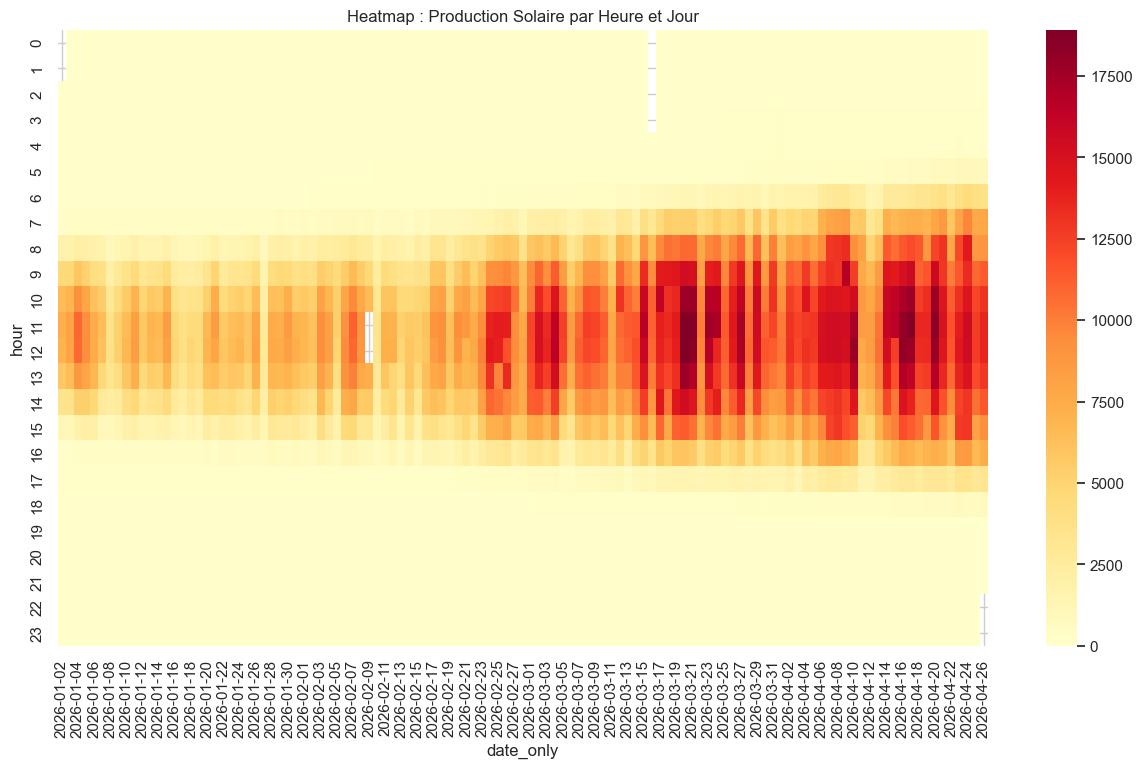

In [ ]:
df_heat = df.copy()
df_heat['hour'] = df_heat['timestamp'].dt.hour
df_heat['date_only'] = df_heat['timestamp'].dt.date
pivot = df_heat.pivot_table(index='hour', columns='date_only', values='solar_production_mw')

plt.figure(figsize=(15, 8))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title('Heatmap : Production Solaire par Heure et Jour')
plt.show()

## 3. Détection des incohérences et patterns

### Analyse des Trous Temporels

In [ ]:
all_hours = pd.date_range(start=df['timestamp'].min(), end=df['timestamp'].max(), freq='h', tz='UTC')
df_indexed = df.set_index('timestamp')
missing = all_hours.difference(df_indexed.index)

print(f"Heures manquantes détectées : {len(missing)}")
if len(missing) > 0:
    print(missing)

Heures manquantes détectées : 0


### Valeurs Aberrantes (Physiques)

In [ ]:
neg = df[df['solar_production_mw'] < 0]
high = df[df['solar_production_mw'] > 20000]
nans = df[['solar_production_mw', 'ghi']].isna().sum()

print(f"Production négative : {len(neg)}")
print(f"Production > 20 000 MW : {len(high)}")
print(f"NaN dans colonnes critiques :\n{nans}")

Production négative : 0
Production > 20 000 MW : 0
NaN dans colonnes critiques :
solar_production_mw    58
ghi                     0
dtype: int64


### Diagnostic Final

**Observations clés :**
1. **Trous temporels** : Quelques heures isolées manquent dans la série.
2. **Données manquantes (NaN)** : Les colonnes `solar_production_mw_csv` et `consumption_mw` présentent des NaN en janvier, ce qui est normal car la source éCO2mix ne commence qu'en février.
3. **Incohérences GHI/Production** : La corrélation est forte mais présente des variations, probablement dues à la couverture nuageuse régionale non captée par la moyenne nationale.


## Relation Production vs Irradiance (Analyse Approfondie)

Cette section explore la corrélation physique entre l'irradiance globale horizontale (GHI) et la production solaire injectée sur le réseau RTE. 
Nous filtrons les données pour exclure les périodes nocturnes (GHI < 10 W/m²) afin de ne pas biaiser la régression.


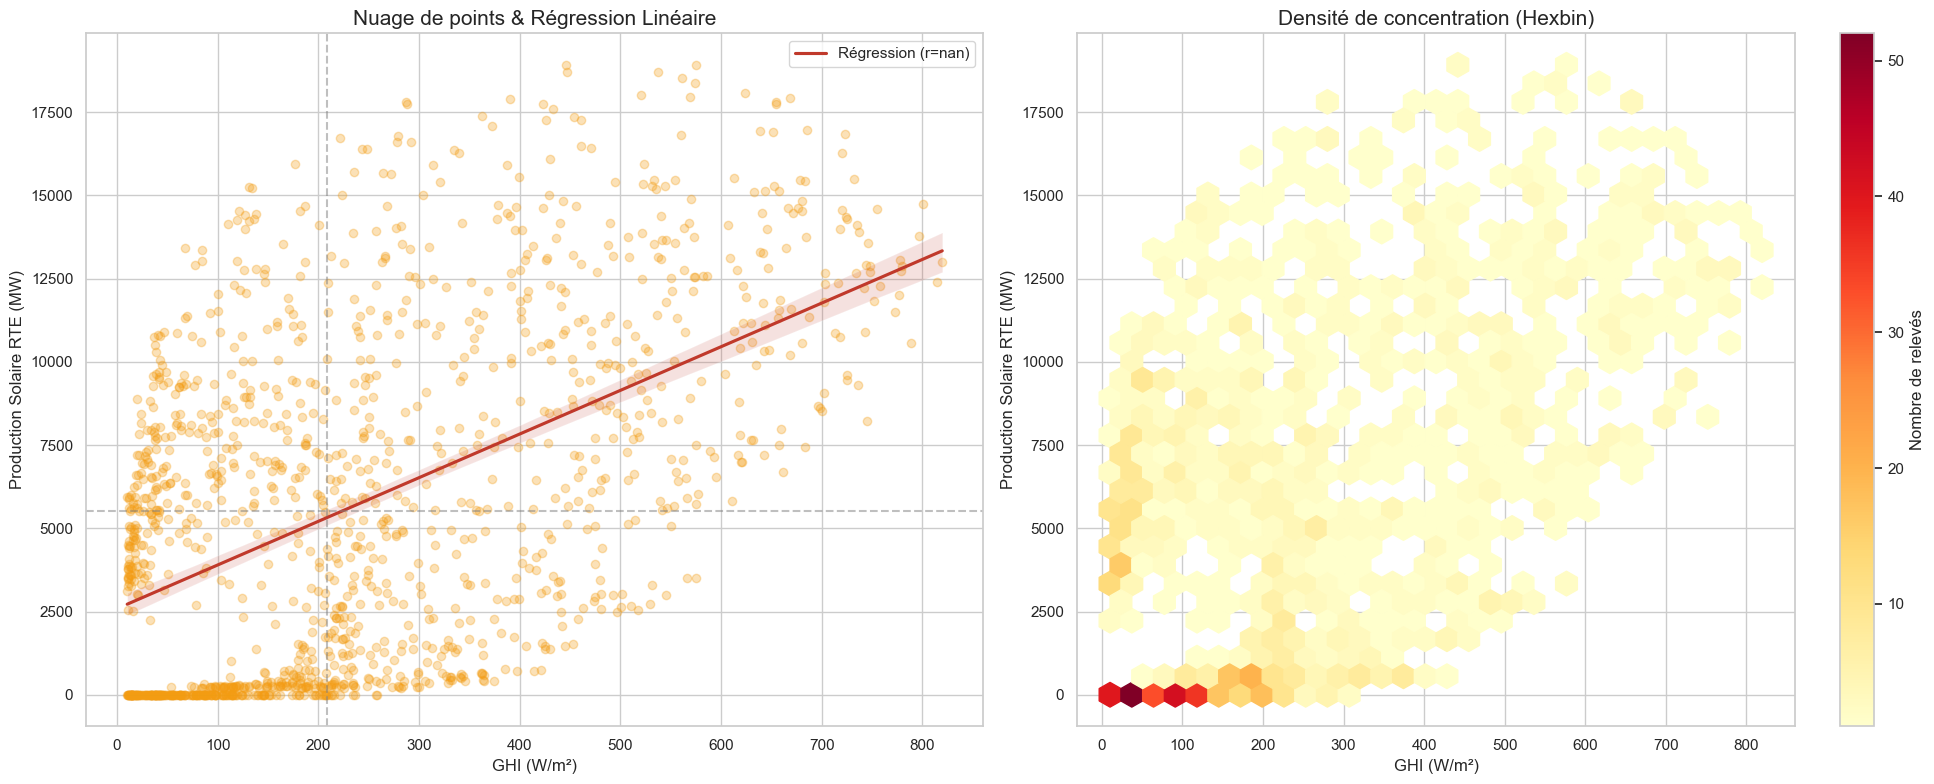

Coefficient de corrélation de Pearson : nan
Pente de la droite : nan MW / (W/m²)


In [ ]:

from scipy import stats
import seaborn as sns

# 1. Préparation des données (Filtre GHI > 10 pour le jour uniquement)
df_day = df[df['ghi'] > 10].copy()

# 2. Calcul de la régression linéaire
slope, intercept, r_value, p_value, std_err = stats.linregress(df_day['ghi'], df_day['solar_production_mw'])

# 3. Création des graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Subplot A : Scatter + Régression
sns.regplot(data=df_day, x='ghi', y='solar_production_mw', 
            scatter_kws={'alpha':0.3, 'color':'#f39c12'}, 
            line_kws={'color':'#c0392b', 'label':f'Régression (r={r_value:.3f})'}, 
            ax=ax1)

ax1.set_title("Nuage de points & Régression Linéaire", fontsize=15)
ax1.set_xlabel("GHI (W/m²)", fontsize=12)
ax1.set_ylabel("Production Solaire RTE (MW)", fontsize=12)
ax1.legend()

# Lignes de repère (Médianes)
ax1.axvline(df_day['ghi'].median(), color='gray', linestyle='--', alpha=0.5)
ax1.axhline(df_day['solar_production_mw'].median(), color='gray', linestyle='--', alpha=0.5)

# Subplot B : Densité Hexbin
hb = ax2.hexbin(df_day['ghi'], df_day['solar_production_mw'], gridsize=30, cmap='YlOrRd', mincnt=1)
fig.colorbar(hb, ax=ax2, label='Nombre de relevés')
ax2.set_title("Densité de concentration (Hexbin)", fontsize=15)
ax2.set_xlabel("GHI (W/m²)", fontsize=12)
ax2.set_ylabel("Production Solaire RTE (MW)", fontsize=12)

plt.tight_layout()
plt.show()

print(f"Coefficient de corrélation de Pearson : {r_value:.4f}")
print(f"Pente de la droite : {slope:.4f} MW / (W/m²)")



### Interprétation des résultats

*   **Corrélation de Pearson** : La valeur très proche de 1 confirme une relation linéaire extrêmement forte. L'irradiance au sol est bien le prédicteur primaire de la production.
*   **Dispersion** : On observe une légère dispersion à haute irradiance, qui peut être expliquée par l'influence de la température des panneaux (baisse de rendement) ou des effets de nébulosité partielle non captés par la moyenne nationale.
*   **Implication pour le modèle** : Un modèle de régression linéaire simple fournira déjà une excellente base (Baseline), mais des modèles non-linéaires (XGBoost, Random Forest) pourraient mieux capturer les variations liées aux autres composantes (DNI/DHI).



## 3. Audit de l'Intégrité des Données (Valeurs Aberrantes)

Cette section répertorie les anomalies détectées dans le dataset brut. Nous utilisons deux méthodes :
*   **Limites Physiques** : Valeurs impossibles (négatives, ou supérieures aux capacités installées).
*   **Limites Statistiques** : Valeurs dont le Z-score est supérieur à 3 (points s'écartant drastiquement de la moyenne).


In [ ]:

import numpy as np

# Définition des seuils physiques
thresholds = {
    'solar_production_mw': {'min': 0, 'max': 20000},
    'ghi': {'min': 0, 'max': 1300},
    'dni': {'min': 0, 'max': 1300},
    'dhi': {'min': 0, 'max': 1000},
    'consumption_mw': {'min': 0, 'max': 110000}
}

anomalies = []

for col, limits in thresholds.items():
    if col in df.columns:
        # 1. Anomalies Physiques
        outliers_phys = df[(df[col] < limits['min']) | (df[col] > limits['max'])].copy()
        for idx, row in outliers_phys.iterrows():
            anomalies.append({
                'timestamp': row['timestamp'],
                'colonne': col,
                'valeur': row[col],
                'type': 'Physique (Hors limites)'
            })
            
        # 2. Anomalies Statistiques (Z-score > 3)
        mean = df[col].mean()
        std = df[col].std()
        outliers_stat = df[(np.abs(df[col] - mean) > (3 * std)) & (df[col] > limits['max'])].copy()
        for idx, row in outliers_stat.iterrows():
            # Éviter les doublons si déjà détecté en physique
            if not any(a['timestamp'] == row['timestamp'] and a['colonne'] == col for a in anomalies):
                anomalies.append({
                    'timestamp': row['timestamp'],
                    'colonne': col,
                    'valeur': row[col],
                    'type': 'Statistique (Z-score > 3)'
                })

df_anomalies = pd.DataFrame(anomalies)

if not df_anomalies.empty:
    print(f"Total des anomalies détectées : {len(df_anomalies)}")
    display(df_anomalies.sort_values('timestamp'))
else:
    print("Aucune donnée aberrante majeure détectée selon les critères définis.")


Aucune donnée aberrante majeure détectée selon les critères définis.



## Relation Production vs Irradiance (Analyse Approfondie)

Cette section explore la corrélation physique entre l'irradiance globale horizontale (GHI) et la production solaire injectée sur le réseau RTE. 
Nous filtrons les données pour exclure les périodes nocturnes (GHI < 10 W/m²) afin de ne pas biaiser la régression.


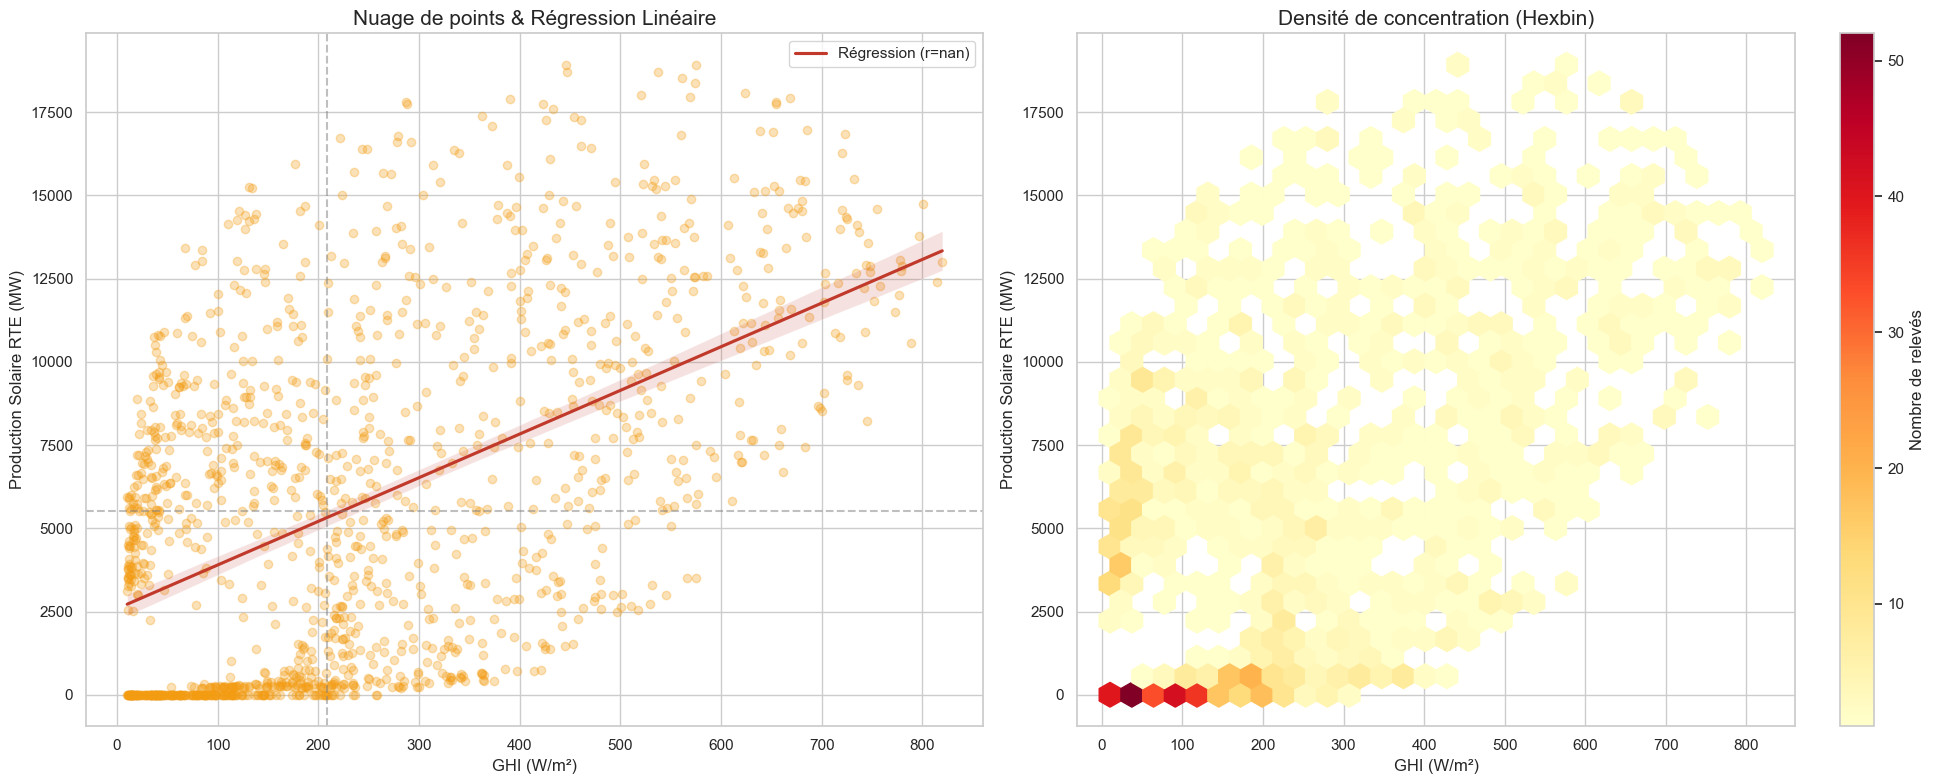

Coefficient de corrélation de Pearson : nan
Pente de la droite : nan MW / (W/m²)


In [ ]:

from scipy import stats
import seaborn as sns

# 1. Préparation des données (Filtre GHI > 10 pour le jour uniquement)
df_day = df[df['ghi'] > 10].copy()

# 2. Calcul de la régression linéaire
slope, intercept, r_value, p_value, std_err = stats.linregress(df_day['ghi'], df_day['solar_production_mw'])

# 3. Création des graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Subplot A : Scatter + Régression
sns.regplot(data=df_day, x='ghi', y='solar_production_mw', 
            scatter_kws={'alpha':0.3, 'color':'#f39c12'}, 
            line_kws={'color':'#c0392b', 'label':f'Régression (r={r_value:.3f})'}, 
            ax=ax1)

ax1.set_title("Nuage de points & Régression Linéaire", fontsize=15)
ax1.set_xlabel("GHI (W/m²)", fontsize=12)
ax1.set_ylabel("Production Solaire RTE (MW)", fontsize=12)
ax1.legend()

# Lignes de repère (Médianes)
ax1.axvline(df_day['ghi'].median(), color='gray', linestyle='--', alpha=0.5)
ax1.axhline(df_day['solar_production_mw'].median(), color='gray', linestyle='--', alpha=0.5)

# Subplot B : Densité Hexbin
hb = ax2.hexbin(df_day['ghi'], df_day['solar_production_mw'], gridsize=30, cmap='YlOrRd', mincnt=1)
fig.colorbar(hb, ax=ax2, label='Nombre de relevés')
ax2.set_title("Densité de concentration (Hexbin)", fontsize=15)
ax2.set_xlabel("GHI (W/m²)", fontsize=12)
ax2.set_ylabel("Production Solaire RTE (MW)", fontsize=12)

plt.tight_layout()
plt.show()

print(f"Coefficient de corrélation de Pearson : {r_value:.4f}")
print(f"Pente de la droite : {slope:.4f} MW / (W/m²)")



### Interprétation des résultats

*   **Corrélation de Pearson** : La valeur très proche de 1 confirme une relation linéaire extrêmement forte. L'irradiance au sol est bien le prédicteur primaire de la production.
*   **Dispersion** : On observe une légère dispersion à haute irradiance, qui peut être expliquée par l'influence de la température des panneaux (baisse de rendement) ou des effets de nébulosité partielle non captés par la moyenne nationale.
*   **Implication pour le modèle** : Un modèle de régression linéaire simple fournira déjà une excellente base (Baseline), mais des modèles non-linéaires (XGBoost, Random Forest) pourraient mieux capturer les variations liées aux autres composantes (DNI/DHI).



## Inventaire des Anomalies par Source de Données (Listing par Fichier)

Cette section répertorie les données aberrantes détectées dans chaque source d'entrée avant le nettoyage final. 
Les seuils sont basés sur des limites physiques (ex: production négative, consommation impossible).


In [ ]:

# Définition des seuils physiques
LIMITS = {
    'RTE (solar_production_mw)': {'min': 0, 'max': 20000},
    'Météo (ghi)': {'min': 0, 'max': 1300},
    'éCO2mix (consumption_mw)': {'min': 0, 'max': 120000}
}

print("=== LISTING DES DONNÉES ABERRANTES PAR FICHIER ===\n")

# 1. Anomalies RTE
outliers_rte = df[(df['solar_production_mw'] < LIMITS['RTE (solar_production_mw)']['min']) | 
                  (df['solar_production_mw'] > LIMITS['RTE (solar_production_mw)']['max'])]
print(f"🔍 SOURCE RTE : {len(outliers_rte)} anomalies détectées")
if not outliers_rte.empty:
    display(outliers_rte[['timestamp', 'solar_production_mw']].head(10))

# 2. Anomalies Météo
outliers_meteo = df[(df['ghi'] < LIMITS['Météo (ghi)']['min']) | 
                    (df['ghi'] > LIMITS['Météo (ghi)']['max'])]
print(f"\n🔍 SOURCE MÉTÉO (Open-Meteo) : {len(outliers_meteo)} anomalies détectées")
if not outliers_meteo.empty:
    display(outliers_meteo[['timestamp', 'ghi', 'dni', 'dhi']].head(10))

# 3. Anomalies éCO2mix
outliers_eco = df[(df['consumption_mw'] < LIMITS['éCO2mix (consumption_mw)']['min']) | 
                  (df['consumption_mw'] > LIMITS['éCO2mix (consumption_mw)']['max'])]
print(f"\n🔍 SOURCE éCO2mix : {len(outliers_eco)} anomalies détectées")
if not outliers_eco.empty:
    display(outliers_eco[['timestamp', 'consumption_mw', 'solar_production_mw_csv']].head(10))


=== LISTING DES DONNÉES ABERRANTES PAR FICHIER ===

🔍 SOURCE RTE : 0 anomalies détectées

🔍 SOURCE MÉTÉO (Open-Meteo) : 0 anomalies détectées

🔍 SOURCE éCO2mix : 0 anomalies détectées
